## Logistic Regression using Single Layer Perceptron Neural Network (SLPNN)

In [156]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:\\Users\\ACER\\Downloads\\archive\\glass.csv")
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [157]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [158]:
print(df.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [159]:
print(df.shape)

(214, 10)


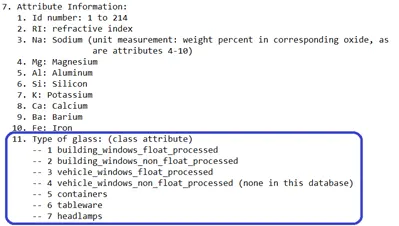

In [160]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [161]:
def feedforward(X, weights):
    return sigmoid(np.dot(X, weights))

In [162]:
def cross_entropy_loss(weights, h, y):
    eps = 1e-9   # to avoid log(0)
    h = np.clip(h, eps, 1 - eps)
    error = -y * np.log(h) - (1 - y) * np.log(1 - h)
    return np.mean(error)

In [163]:
def backprop(X, h, y):
    delta = np.dot(X.T, (h - y)) / y.size
    return delta

def update_weights(weights, delta, learning_rate):
    weights -= learning_rate * delta
    return weights

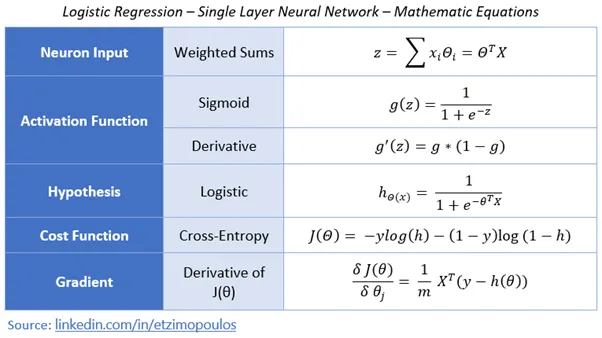

In [164]:
def predict(X, weights):
    prob = feedforward(X, weights)
    return prob >= 0.5

In [165]:
def classify(y_pred):
    return np.where(y_pred, 1, 0)

In [166]:
def train(X, y, lr, epochs):
    weights = np.zeros(X.shape[1])

    for epoch in range(epochs):
        h = feedforward(X, weights)
        loss = cross_entropy_loss(weights, h, y)
        delta = backprop(X, h, y)
        weights = update_weights(weights, delta, lr)
        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss}')
    return weights

In [169]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

lr = 0.005
epochs = 10000

X = df.drop('Type', axis=1).values
y = df['Type'].values

# scaler = StandardScaler()
# X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

weights = train(X_train, y_train, lr, epochs)
y_pred = predict(X_test, weights)
accuracy = np.mean(classify(y_pred) == y_test)
print(f'Accuracy: {accuracy * 100}%')

Epoch 0, Loss: 0.6931471805599454
Epoch 100, Loss: -38.05324842805087
Epoch 200, Loss: -38.05324842805087
Epoch 300, Loss: -38.05324842805087
Epoch 400, Loss: -38.05324842805087
Epoch 500, Loss: -38.05324842805087
Epoch 600, Loss: -38.05324842805087
Epoch 700, Loss: -38.05324842805087
Epoch 800, Loss: -38.05324842805087
Epoch 900, Loss: -38.05324842805087
Epoch 1000, Loss: -38.05324842805087
Epoch 1100, Loss: -38.05324842805087
Epoch 1200, Loss: -38.05324842805087
Epoch 1300, Loss: -38.05324842805087
Epoch 1400, Loss: -38.05324842805087
Epoch 1500, Loss: -38.05324842805087
Epoch 1600, Loss: -38.05324842805087
Epoch 1700, Loss: -38.05324842805087
Epoch 1800, Loss: -38.05324842805087
Epoch 1900, Loss: -38.05324842805087
Epoch 2000, Loss: -38.05324842805087
Epoch 2100, Loss: -38.05324842805087
Epoch 2200, Loss: -38.05324842805087
Epoch 2300, Loss: -38.05324842805087
Epoch 2400, Loss: -38.05324842805087
Epoch 2500, Loss: -38.05324842805087
Epoch 2600, Loss: -38.05324842805087
Epoch 2700, L